CODE
___________________________________________________________________
ASSIGNMENT 1
(CONCEPT LEARNING) 
___________________________________________________________________
Group # 60, 
GROUP MEMBERS: 
ASRA ANEES &
ALI ABDULLAH


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.model_selection import train_test_split


In [2]:
def main():
    file_name = "/content/spambase.data"
    data_frame = load_data(file_name)
    data_info(file_name,data_frame)
    num_of_bins = 50
    info(num_of_bins,data_frame)
    X, y = preprocess_data(data_frame, num_of_bins)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    m = train_model(X_train, y_train)
    pred = test_model(X_test, y_test, m)
    metrics = compute_metrics(y_test, pred)
    print_metrics(metrics)
    print_rule(m)

# Data Exploration

In [3]:
def data_info(file_name,data_frame):
  # Reading the spambase.data into pandas data frame
  spambase_name = []
  with open('/content/spambase.names') as f:
    spambase_name = f.read()
    splitingName = spambase_name.split(sep='\n')
    splitingName [33:]
    colume_name = []
  for line in splitingName [33:]:
    matched = re.split(r':.*$', line)
    colume_name.append(matched[0])

  colume_name = colume_name[:-1]
  colume_name.append('spam')
  #Reading the spam_data with names of columns
  df = pd.read_csv(file_name, header=None, delimiter=",", dtype=np.float32, names=colume_name)
  data = df.to_numpy()
  print("\n------------ Information about data set ------------------\n") 
  df.info()
  print("\n______________________________________________________________")
  print("\n------- visual representation of emails in Spam not ------\n")
  sns.countplot(x='spam',hue='spam',data=df,palette = "Set2")
  plt.show()



# Data Processing: Finding Hypothesis space and applying LGG rule

In [4]:
# Loads data from a CSV file and returns a Pandas DataFrame.
def load_data(file_name):
    return pd.read_csv(file_name, header=None, delimiter=",", dtype=np.float32)

In [5]:
 # Preprocesses the data by transforming continuous features into discrete values using binning and scaling.
def preprocess_data(data_frame,num_of_bins):
    X = data_frame.iloc[:, :-1]  # Select all columns except the last
    y = data_frame.iloc[:, -1]   # Select the last column
    # Instantiate a StandardScaler object
    scale = StandardScaler()     
    X = scale.fit_transform(X)
    # Instantiate a KBinsDiscretizer object
    ds = KBinsDiscretizer(num_of_bins, encode='ordinal')
    X = ds.fit_transform(X)
    return X, y

In [6]:
# Trains a model using the LGG(z) and LGG-Conj(x, y) algorithms.
def train_model(X_train, y_train):
    # Finds the least general generalization of the data in z.
    def LGG(z):
        LeastGeneralGeneralization = z[0]
        for x in z[1:]:
            LeastGeneralGeneralization = LGGConjuction(LeastGeneralGeneralization, x)
        return LeastGeneralGeneralization
      
    # Finds the least general generalization of x and y.  
    def LGGConjuction(x, y):
        LeastGeneralGeneralization = []
        for i in range(len(x)):
            if x[i] == y[i]:
                LeastGeneralGeneralization.append(i)
        return LeastGeneralGeneralization

    return LGG(X_train)



In [7]:
# Tests the model's (m) performance on a test set.
def test_model(X_test, y_test, m):
    pred = []
    for x in X_test:
        val = x in m
        pred.append(val)
    return pred

In [8]:
# Computes and returns various performance metrics for the model.
def compute_metrics(y_test, pred):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    true_negative, false_positive, false_negative, true_positive = confusion_matrix(y_test, pred).ravel()
    specificity = true_negative / (true_negative + false_positive)
    false_positive_rate = false_positive / (false_positive + true_negative)
    false_negative_rate = false_negative / (false_negative + true_positive)
    f1_score_val = f1_score(y_test, pred)
    return accuracy, precision, recall, specificity, false_positive_rate, false_negative_rate, f1_score_val

In [9]:
# Printing the information about size of bin, hypothesis space and conjunctions
def info(num_of_bins,data_frame):
    print("\n----------------------------Information-------------------\n")
    # prninting the information about model 
    print("Number of bins:        " + str(num_of_bins))
    print("Hypothesis concept:    2^(" + str(num_of_bins) + "^57) for " + str(num_of_bins) + " bins")
    print("Hypothesis Space Size: 2^" + str(num_of_bins ** data_frame.shape[1]))
    print("Conjunctive concept:   " + str(num_of_bins + 1) + "^57 for " + str(num_of_bins) + " bins")
    print("No. of conjunctions:   " + str((num_of_bins + 1) ** data_frame.shape[1]))

In [10]:
# Prints the performance metrics for the model.
def print_metrics(metrics):
    accuracy, precision, recall, specificity, false_positive_rate, false_negative_rate, f1_score_val = metrics
    print("\n__________________________________________________________")
    print("\n---------------------Confusion matrix-------------------\n")
    print("ACCURACY:              " + str(round(accuracy*100, 3)) + " %")
    print("PRECISION:             " + str(round(precision*100, 3)) + " %")
    print("RECALL:                " + str(round(recall*100, 3)) + " %")
    print("SPECIFICITY:           " + str(round(specificity*100,3)) + " %")
    print("FALSE POSITIVE RATE:   " + str(round(false_positive_rate*100, 3)) + " %")
    print("FALSE NEGATIVE RATE:   " + str(round(false_negative_rate*100, 3)) + " %")
    print("\n__________________________________________________________")

In [11]:
# Prints the least general generalization rule for the model m.
def print_rule(m):
    print("\n----The least general generalization rule for the first 57 features-----\n")
    print(m)


------------ Information about data set ------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float32
 1   word_freq_address           4601 non-null   float32
 2   word_freq_all               4601 non-null   float32
 3   word_freq_3d                4601 non-null   float32
 4   word_freq_our               4601 non-null   float32
 5   word_freq_over              4601 non-null   float32
 6   word_freq_remove            4601 non-null   float32
 7   word_freq_internet          4601 non-null   float32
 8   word_freq_order             4601 non-null   float32
 9   word_freq_mail              4601 non-null   float32
 10  word_freq_receive           4601 non-null   float32
 11  word_freq_will              4601 non-null   float32
 12  word_freq_people            4

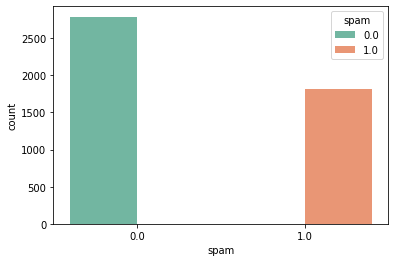


----------------------------Information-------------------

Number of bins:        50
Hypothesis concept:    2^(50^57) for 50 bins
Hypothesis Space Size: 2^346944695195361418882384896278381347656250000000000000000000000000000000000000000000000000000000000
Conjunctive concept:   51^57 for 50 bins
No. of conjunctions:   1094133243748590861676605021951259049155035926175307785992922537835464300221280367657016723048635401


/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 2 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_discretization.py:279: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_discretization.py:279: Use


__________________________________________________________

---------------------Confusion matrix-------------------

ACCURACY:              57.655 %
PRECISION:             0.0 %
RECALL:                0.0 %
SPECIFICITY:           100.0 %
FALSE POSITIVE RATE:   0.0 %
FALSE NEGATIVE RATE:   100.0 %

__________________________________________________________

----The least general generalization rule for the first 57 features-----

[]


In [12]:
if __name__=="__main__": main()